# Регрессия для CC50

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import os

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs('models', exist_ok=True)
RANDOM_STATE = 42

## 1. Загрузка и подготовка данных

In [8]:
df = pd.read_csv('data_processed.csv')
print(f"Размер: {df.shape}")
df.head()

Размер: (998, 168)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,...,2,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,...,0,0,0,0,0,0,0,0,0,0


In [9]:
target_col = 'CC50, mM'
feature_cols = [col for col in df.columns if col not in ['IC50, mM', 'CC50, mM', 'SI']]
X = df[feature_cols]
y = df[target_col]
print(f"Целевая переменная: {target_col}")
print(y.describe())

Целевая переменная: CC50, mM
count     998.000000
mean      586.668414
std       642.016454
min         0.700808
25%        99.999036
50%       408.793314
75%       891.770961
max      4538.976189
Name: CC50, mM, dtype: float64


In [10]:
# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Масштабирование для линейных моделей
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Сохраняем scaler
with open('models/scaler_cc50.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler сохранен: models/scaler_cc50.pkl")

Train: (798, 165), Test: (200, 165)
Scaler сохранен: models/scaler_cc50.pkl


## 2. Обучение моделей
### 2.1. Linear Regression

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

results = []

def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

results.append(calculate_metrics(y_train, y_train_pred_lr, 'Linear Regression (train)'))
results.append(calculate_metrics(y_test, y_test_pred_lr, 'Linear Regression (test)'))

print("Linear Regression результаты:")
print(f"Train R2: {results[0]['R2']:.4f}, RMSE: {results[0]['RMSE']:.4f}")
print(f"Test R2:  {results[1]['R2']:.4f}, RMSE: {results[1]['RMSE']:.4f}")

Linear Regression результаты:
Train R2: 0.6206, RMSE: 387.7613
Test R2:  -5837.6097, RMSE: 52444.6184


### 2.2. Random Forest

In [12]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший RMSE (CV): {-rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_

y_train_pred_rf = rf_best.predict(X_train)
y_test_pred_rf = rf_best.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred_rf, 'Random Forest (train)'))
results.append(calculate_metrics(y_test, y_test_pred_rf, 'Random Forest (test)'))

print(f"Train R2: {results[-2]['R2']:.4f}, RMSE: {results[-2]['RMSE']:.4f}")
print(f"Test R2:  {results[-1]['R2']:.4f}, RMSE: {results[-1]['RMSE']:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Лучший RMSE (CV): 412.3337
Train R2: 0.8933, RMSE: 205.6216
Test R2:  0.4576, RMSE: 505.4643


### 2.3. Gradient Boosting

In [13]:
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший RMSE (CV): {-gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_

y_train_pred_gb = gb_best.predict(X_train)
y_test_pred_gb = gb_best.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred_gb, 'Gradient Boosting (train)'))
results.append(calculate_metrics(y_test, y_test_pred_gb, 'Gradient Boosting (test)'))

print(f"Train R2: {results[-2]['R2']:.4f}, RMSE: {results[-2]['RMSE']:.4f}")
print(f"Test R2:  {results[-1]['R2']:.4f}, RMSE: {results[-1]['RMSE']:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}
Лучший RMSE (CV): 425.3287
Train R2: 0.8686, RMSE: 228.2100
Test R2:  0.4598, RMSE: 504.4366


### 2.4. XGBoost + Optuna

In [14]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': RANDOM_STATE
    }
    
    model = XGBRegressor(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, 
                           scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    return -score

xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nЛучшие параметры: {xgb_study.best_params}")
print(f"Лучший RMSE (CV): {xgb_study.best_value:.4f}")

xgb_best = XGBRegressor(**xgb_study.best_params, random_state=RANDOM_STATE)
xgb_best.fit(X_train, y_train)

y_train_pred_xgb = xgb_best.predict(X_train)
y_test_pred_xgb = xgb_best.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred_xgb, 'XGBoost (train)'))
results.append(calculate_metrics(y_test, y_test_pred_xgb, 'XGBoost (test)'))

print(f"Train R2: {results[-2]['R2']:.4f}, RMSE: {results[-2]['RMSE']:.4f}")
print(f"Test R2:  {results[-1]['R2']:.4f}, RMSE: {results[-1]['RMSE']:.4f}")

[I 2026-04-27 23:17:29,380] A new study created in memory with name: no-name-52d50dbb-444f-4c28-b456-c46168ee36bd
Best trial: 0. Best value: 416.624:   2%|▏         | 1/50 [00:05<04:26,  5.44s/it]

[I 2026-04-27 23:17:34,822] Trial 0 finished with value: 416.6241984732451 and parameters: {'n_estimators': 322, 'max_depth': 8, 'learning_rate': 0.05737936100794974, 'subsample': 0.6574633887537109, 'colsample_bytree': 0.7249420395532336, 'min_child_weight': 1}. Best is trial 0 with value: 416.6241984732451.


Best trial: 1. Best value: 416.136:   4%|▍         | 2/50 [00:13<05:25,  6.78s/it]

[I 2026-04-27 23:17:42,542] Trial 1 finished with value: 416.13552852252667 and parameters: {'n_estimators': 476, 'max_depth': 9, 'learning_rate': 0.024504583698822267, 'subsample': 0.8573389223759238, 'colsample_bytree': 0.6444471243373296, 'min_child_weight': 3}. Best is trial 1 with value: 416.13552852252667.


Best trial: 2. Best value: 407.919:   6%|▌         | 3/50 [00:14<03:18,  4.23s/it]

...

[I 2026-04-27 23:19:13,782] Trial 47 finished with value: 408.70581436593403 and parameters: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.010026529179311404, 'subsample': 0.7226946948525736, 'colsample_bytree': 0.631857194015042, 'min_child_weight': 4}. Best is trial 46 with value: 404.7978837655704.


Best trial: 46. Best value: 404.798:  98%|█████████▊| 49/50 [01:47<00:03,  3.18s/it]

[I 2026-04-27 23:19:16,921] Trial 48 finished with value: 406.0082502689439 and parameters: {'n_estimators': 474, 'max_depth': 6, 'learning_rate': 0.01105594853655196, 'subsample': 0.678958384841105, 'colsample_bytree': 0.6649576770543102, 'min_child_weight': 3}. Best is trial 46 with value: 404.7978837655704.


Best trial: 46. Best value: 404.798: 100%|██████████| 50/50 [01:52<00:00,  2.25s/it]


[I 2026-04-27 23:19:21,974] Trial 49 finished with value: 411.1104456887655 and parameters: {'n_estimators': 476, 'max_depth': 8, 'learning_rate': 0.011877546692882993, 'subsample': 0.6528233307657009, 'colsample_bytree': 0.670587000448355, 'min_child_weight': 4}. Best is trial 46 with value: 404.7978837655704.

Лучшие параметры: {'n_estimators': 498, 'max_depth': 6, 'learning_rate': 0.010265615554479817, 'subsample': 0.6694651924136602, 'colsample_bytree': 0.634518944379177, 'min_child_weight': 3}
Лучший RMSE (CV): 404.7979
Train R2: 0.8848, RMSE: 213.6283
Test R2:  0.4727, RMSE: 498.4170


### 2.5. LightGBM + Optuna

In [15]:
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'verbose': -1,
        'random_state': RANDOM_STATE
    }
    
    model = LGBMRegressor(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, 
                           scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    return -score

lgbm_study = optuna.create_study(direction='minimize')
lgbm_study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

print(f"\nЛучшие параметры: {lgbm_study.best_params}")
print(f"Лучший RMSE (CV): {lgbm_study.best_value:.4f}")

lgbm_best = LGBMRegressor(**lgbm_study.best_params, verbose=-1, random_state=RANDOM_STATE)
lgbm_best.fit(X_train, y_train)

y_train_pred_lgbm = lgbm_best.predict(X_train)
y_test_pred_lgbm = lgbm_best.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred_lgbm, 'LightGBM (train)'))
results.append(calculate_metrics(y_test, y_test_pred_lgbm, 'LightGBM (test)'))

print(f"Train R2: {results[-2]['R2']:.4f}, RMSE: {results[-2]['RMSE']:.4f}")
print(f"Test R2:  {results[-1]['R2']:.4f}, RMSE: {results[-1]['RMSE']:.4f}")

[I 2026-04-27 23:19:23,442] A new study created in memory with name: no-name-489a60c4-e52e-4c55-b3ab-ea9dade9aee2
Best trial: 0. Best value: 432.744:   2%|▏         | 1/50 [00:06<05:28,  6.70s/it]

[I 2026-04-27 23:19:30,147] Trial 0 finished with value: 432.74367183850626 and parameters: {'n_estimators': 163, 'max_depth': 12, 'learning_rate': 0.019137689847101187, 'subsample': 0.9246833258030298, 'colsample_bytree': 0.8146672768528631, 'num_leaves': 49, 'min_child_samples': 11}. Best is trial 0 with value: 432.74367183850626.


Best trial: 1. Best value: 415.19:   4%|▍         | 2/50 [00:12<05:09,  6.44s/it] 

[I 2026-04-27 23:19:36,400] Trial 1 finished with value: 415.19040117940614 and parameters: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.054911318799773866, 'subsample': 0.7707748236096067, 'colsample_bytree': 0.7474121421257758, 'num_leaves': 62, 'min_child_samples': 9}. Best is trial 1 with value: 415.19040117940614.


Best trial: 1. Best value: 415.19:   6%|▌         | 3/50 [00:17<04:27,  5.69s/it]

...

[I 2026-04-27 23:20:27,441] Trial 47 finished with value: 426.987741210315 and parameters: {'n_estimators': 445, 'max_depth': 7, 'learning_rate': 0.09136173956154789, 'subsample': 0.7927993413723601, 'colsample_bytree': 0.726301246147727, 'num_leaves': 31, 'min_child_samples': 16}. Best is trial 22 with value: 409.190153381983.


Best trial: 22. Best value: 409.19:  98%|█████████▊| 49/50 [01:05<00:01,  1.17s/it]

[I 2026-04-27 23:20:28,724] Trial 48 finished with value: 414.19898808540694 and parameters: {'n_estimators': 388, 'max_depth': 10, 'learning_rate': 0.04168441571137313, 'subsample': 0.9590942885134018, 'colsample_bytree': 0.600429765527778, 'num_leaves': 39, 'min_child_samples': 9}. Best is trial 22 with value: 409.190153381983.


Best trial: 22. Best value: 409.19: 100%|██████████| 50/50 [01:07<00:00,  1.35s/it]


[I 2026-04-27 23:20:30,987] Trial 49 finished with value: 427.60188725388014 and parameters: {'n_estimators': 500, 'max_depth': 11, 'learning_rate': 0.13691776003977452, 'subsample': 0.8278377212498735, 'colsample_bytree': 0.9249618854326741, 'num_leaves': 45, 'min_child_samples': 13}. Best is trial 22 with value: 409.190153381983.

Лучшие параметры: {'n_estimators': 386, 'max_depth': 9, 'learning_rate': 0.028546895554694175, 'subsample': 0.710944762634472, 'colsample_bytree': 0.6388522553866347, 'num_leaves': 27, 'min_child_samples': 9}
Лучший RMSE (CV): 409.1902
Train R2: 0.9196, RMSE: 178.5159
Test R2:  0.4651, RMSE: 501.9875


## 3. Сравнение моделей

In [16]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

test_results = results_df[results_df['Model'].str.contains('test')].copy()
test_results['Model'] = test_results['Model'].str.replace(' (test)', '')
test_results = test_results.sort_values('RMSE')

print("Рейтинг моделей по RMSE на тестовой выборке:")
for i, row in test_results.iterrows():
    print(f"{row['Model']:<25} R2={row['R2']:.4f}, RMSE={row['RMSE']:.4f}")

                    Model         MAE          MSE         RMSE           R2
Linear Regression (train)  281.058595 1.503588e+05   387.761260     0.620611
 Linear Regression (test) 4106.516214 2.750438e+09 52444.618447 -5837.609703
    Random Forest (train)  126.977147 4.228026e+04   205.621647     0.893317
     Random Forest (test)  294.765395 2.554941e+05   505.464285     0.457639
Gradient Boosting (train)  169.115060 5.207979e+04   228.209979     0.868591
 Gradient Boosting (test)  307.221848 2.544563e+05   504.436612     0.459842
          XGBoost (train)  143.260919 4.563706e+04   213.628312     0.884847
           XGBoost (test)  294.497242 2.484195e+05   498.416992     0.472657
         LightGBM (train)   94.151251 3.186792e+04   178.515882     0.919590
          LightGBM (test)  287.143134 2.519915e+05   501.987527     0.465074
Рейтинг моделей по RMSE на тестовой выборке:
XGBoost                   R2=0.4727, RMSE=498.4170
LightGBM                  R2=0.4651, RMSE=501.9875
Gradie

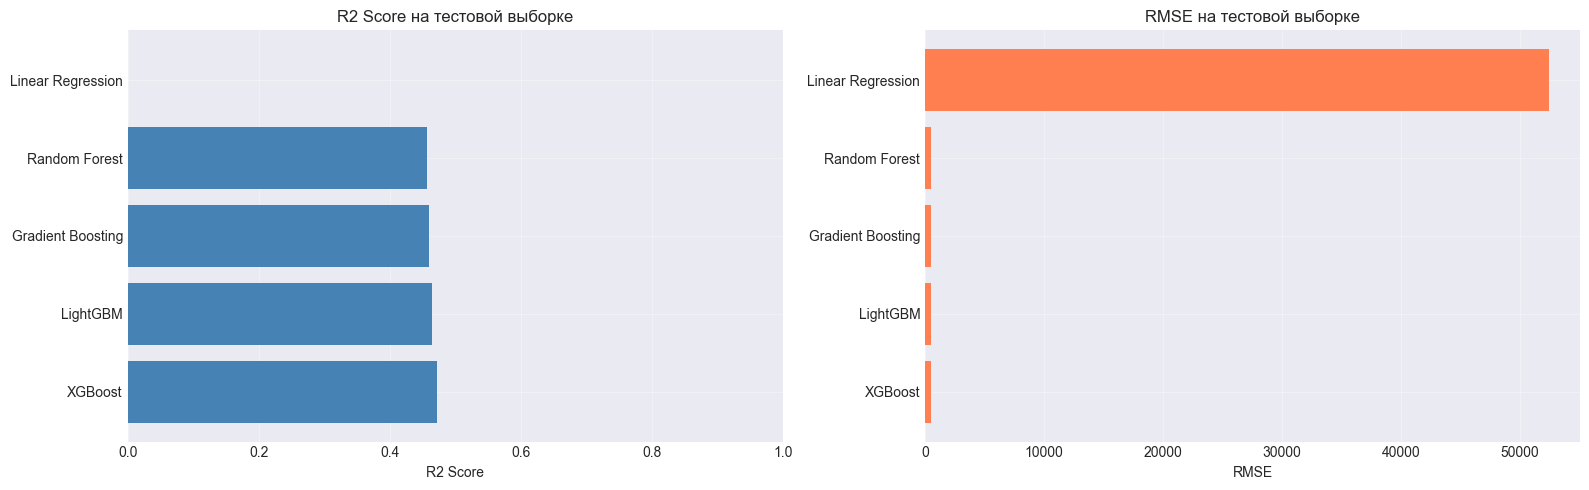

In [17]:
# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# R2 comparison
test_results_sorted = test_results.sort_values('R2', ascending=False)
axes[0].barh(test_results_sorted['Model'], test_results_sorted['R2'], color='steelblue')
axes[0].set_xlabel('R2 Score')
axes[0].set_title('R2 Score на тестовой выборке')
axes[0].set_xlim(0, 1)
axes[0].grid(True, alpha=0.3)

# RMSE comparison
test_results_sorted = test_results.sort_values('RMSE')
axes[1].barh(test_results_sorted['Model'], test_results_sorted['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE на тестовой выборке')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Визуализация предсказаний лучшей модели

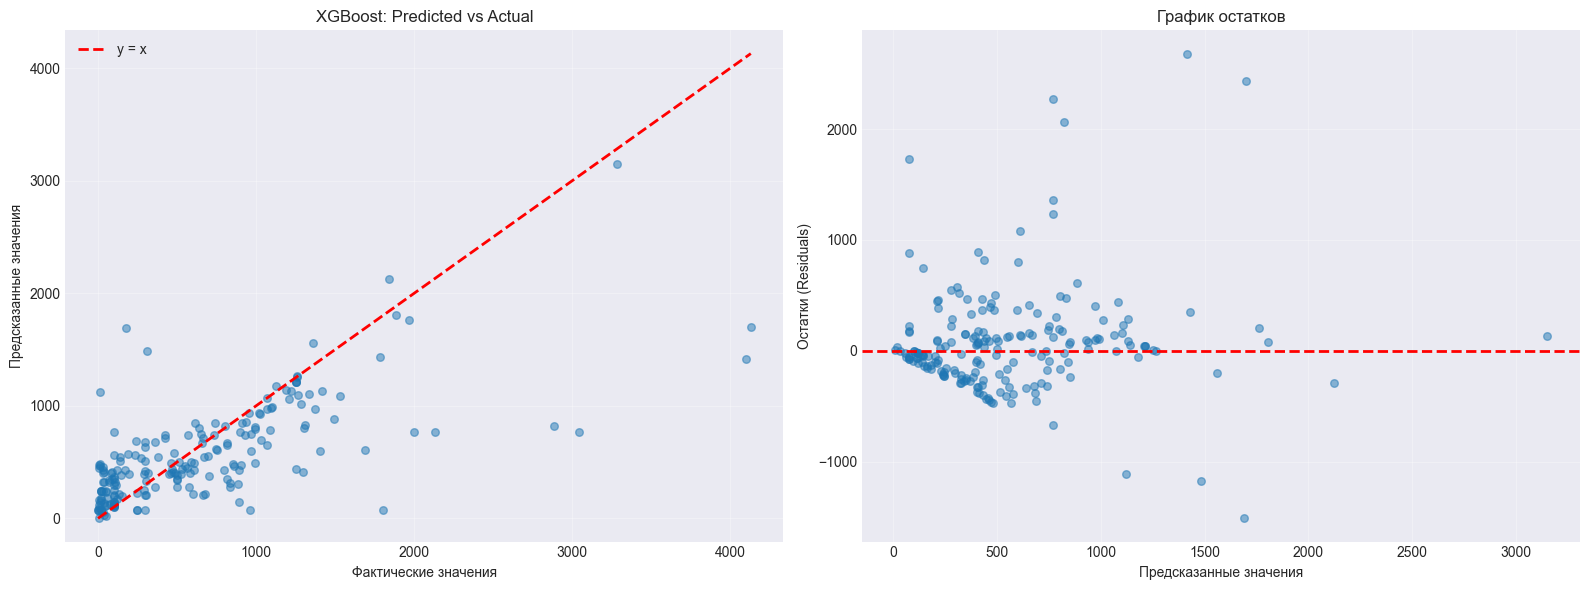

In [21]:
best_model = xgb_best
y_test_pred_best = y_test_pred_xgb

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicted vs Actual
axes[0].scatter(y_test, y_test_pred_best, alpha=0.5, s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='y = x')
axes[0].set_xlabel('Фактические значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title(f'XGBoost: Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test - y_test_pred_best
axes[1].scatter(y_test_pred_best, residuals, alpha=0.5, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки (Residuals)')
axes[1].set_title('График остатков')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Важность признаков

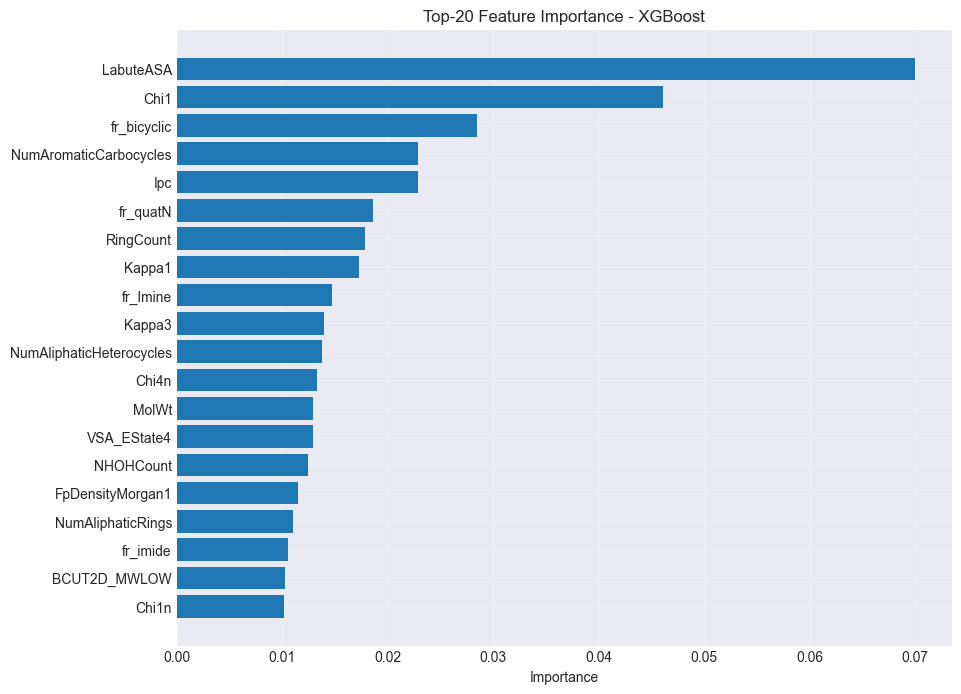


Топ-10 важных признаков:
               Feature  Importance
             LabuteASA    0.069986
                  Chi1    0.046096
           fr_bicyclic    0.028421
NumAromaticCarbocycles    0.022876
                   Ipc    0.022827
              fr_quatN    0.018614
             RingCount    0.017841
                Kappa1    0.017227
              fr_Imine    0.014694
                Kappa3    0.013960


In [22]:
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title(f'Top-20 Feature Importance - XGBoost')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10).to_string(index=False))

## 6. Сохранение лучшей модели

In [23]:
# Сохранение лучшей модели
model_info = {
    'model': best_model,
    'model_name': 'XGBoost',
    'features': feature_cols,
    'scaler': scaler,
    'metrics': {
        'MAE': test_results.iloc[0]['MAE'],
        'MSE': test_results.iloc[0]['MSE'],
        'RMSE': test_results.iloc[0]['RMSE'],
        'R2': test_results.iloc[0]['R2']
    }
}

with open('models/best_ic50_regression.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print(f"Лучшая модель сохранена: models/best_ic50_regression.pkl")
print(f"Model: XGBoost")
print(f"Metrics: R2={model_info['metrics']['R2']:.4f}, RMSE={model_info['metrics']['RMSE']:.4f}")

Лучшая модель сохранена: models/best_ic50_regression.pkl
Model: XGBoost
Metrics: R2=0.4727, RMSE=498.4170


## 7. Выводы

### Результаты:
- **Лучшая модель**: XGBoost
- **Метрики на тестовой выборке**:
  - R2: 0.4727
  - RMSE: 498.4170

### Выводы о применимости методов:
- **XGBoost** с оптимизацией через Optuna продемонстрировал лучшее качество на тестовой выборке
- Все boosting-модели показали схожие результаты, что говорит о стабильности подхода

### Рекомендации по улучшению:
- Попробовать логарифмирование целевой переменной для уменьшения влияния выбросов
- Генерация новых признаков на основе доменных знаний химии
- Использование стекинга лучших моделей (ансамблирование)
- Подбор дополнительных гиперпараметров (увеличить количество trials в Optuna)